<a href="https://colab.research.google.com/github/mbenedicto99/Python4DataScience/blob/master/LSTM_Quantum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DL para analise de trajetoria de Qubits

## LSTM para aprender/predizer a dinâmica de um qubit (mecânica quântica) a partir de séries temporais de observáveis

In [17]:
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [18]:
# Matrizes de Pauli
sx = np.array([[0, 1], [1, 0]], dtype=np.complex128)
sy = np.array([[0, -1j], [1j, 0]], dtype=np.complex128)
sz = np.array([[1, 0], [0, -1]], dtype=np.complex128)
I2 = np.eye(2, dtype=np.complex128)

def unitary_from_hamiltonian(H: np.ndarray, dt: float) -> np.ndarray:
    """U = exp(-i H dt) via diagonalização (2x2)."""
    w, V = np.linalg.eigh(H)
    U = (V * np.exp(-1j * w * dt)) @ V.conj().T
    return U

def bloch_expectations(rho: np.ndarray) -> np.ndarray:
    x = np.real(np.trace(rho @ sx))
    y = np.real(np.trace(rho @ sy))
    z = np.real(np.trace(rho @ sz))
    return np.array([x, y, z], dtype=np.float64)

def pure_state_density(theta: float, phi: float) -> np.ndarray:
    """|ψ> = cos(theta/2)|0> + e^{i phi} sin(theta/2)|1>"""
    a = math.cos(theta/2)
    b = np.exp(1j * phi) * math.sin(theta/2)
    psi = np.array([[a], [b]], dtype=np.complex128)
    rho = psi @ psi.conj().T
    return rho

def simulate_qubit_trajectory(
    omega: float,
    Omega: float,
    dt: float,
    steps: int,
    theta0: float,
    phi0: float,
    meas_noise_std: float = 0.0,
) -> np.ndarray:
    """Retorna série temporal (steps x 3) dos observáveis [<sx>,<sy>,<sz>]."""
    H = 0.5 * omega * sz + 0.5 * Omega * sx
    U = unitary_from_hamiltonian(H, dt)

    rho = pure_state_density(theta0, phi0)
    obs = []
    for _ in range(steps):
        v = bloch_expectations(rho)
        if meas_noise_std > 0:
            v = v + np.random.normal(0.0, meas_noise_std, size=3)
            v = np.clip(v, -1.0, 1.0)
        obs.append(v)
        rho = U @ rho @ U.conj().T
    return np.stack(obs, axis=0)

In [19]:
rng = np.random.default_rng(7)

# Parâmetros físicos
omega = 1.7   # termo em σz
Omega = 2.3   # termo em σx
dt = 0.05
steps = 220

# Dataset
n_traj = 600
meas_noise_std = 0.01

trajectories = []
for _ in range(n_traj):
    theta0 = rng.uniform(0, math.pi)
    phi0 = rng.uniform(0, 2*math.pi)
    traj = simulate_qubit_trajectory(
        omega=omega,
        Omega=Omega,
        dt=dt,
        steps=steps,
        theta0=theta0,
        phi0=phi0,
        meas_noise_std=meas_noise_std,
    )
    trajectories.append(traj)

trajectories = np.stack(trajectories, axis=0)  # (n_traj, steps, 3)
trajectories.shape

(600, 220, 3)

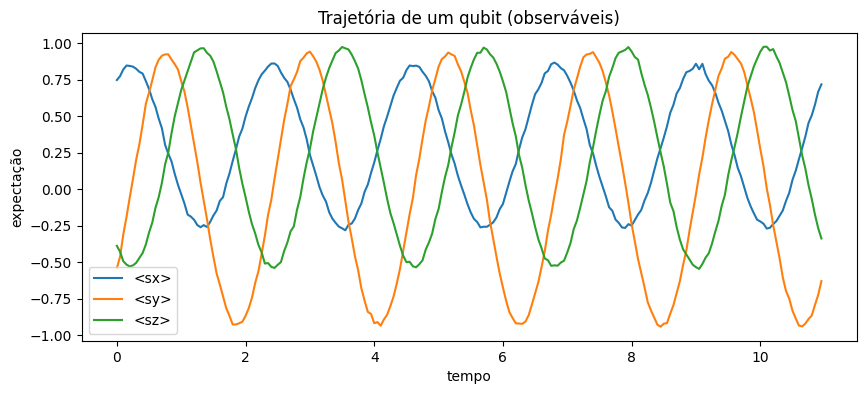

In [20]:
# Visualizar uma trajetória
i = 0
t = np.arange(steps) * dt
plt.figure(figsize=(10,4))
plt.plot(t, trajectories[i,:,0], label='<sx>')
plt.plot(t, trajectories[i,:,1], label='<sy>')
plt.plot(t, trajectories[i,:,2], label='<sz>')
plt.xlabel('tempo')
plt.ylabel('expectação')
plt.title('Trajetória de um qubit (observáveis)')
plt.legend()
plt.show()

In [21]:
class QuantumSeqDataset(torch.utils.data.Dataset):
    def __init__(self, data: np.ndarray, seq_len: int):
        self.data = data.astype(np.float32)
        self.seq_len = seq_len
        self.n_traj, self.steps, self.dim = self.data.shape
        self.valid_t = self.steps - 1

    def __len__(self):
        return self.n_traj * (self.valid_t - self.seq_len)

    def __getitem__(self, idx: int):
        traj_idx = idx // (self.valid_t - self.seq_len)
        t0 = idx % (self.valid_t - self.seq_len)
        t = t0 + self.seq_len - 1
        x = self.data[traj_idx, t-self.seq_len+1:t+1, :]
        y = self.data[traj_idx, t+1, :]
        return x, y

seq_len = 25
n_train = int(0.85 * n_traj)
train_data = trajectories[:n_train]
val_data = trajectories[n_train:]

train_ds = QuantumSeqDataset(train_data, seq_len)
val_ds = QuantumSeqDataset(val_data, seq_len)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, drop_last=False)

len(train_ds), len(val_ds)

(98940, 17460)

In [22]:
class LSTMQuantumPredictor(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=96, num_layers=2, dropout=0.15, out_dim=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, out_dim),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        y = self.head(h_last)
        return y

model = LSTMQuantumPredictor().to(device)
model

LSTMQuantumPredictor(
  (lstm): LSTM(3, 96, num_layers=2, batch_first=True, dropout=0.15)
  (head): Sequential(
    (0): Linear(in_features=96, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [23]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = nn.functional.mse_loss(pred, yb, reduction='sum')
            total_loss += loss.item()
            n += yb.shape[0]
    return total_loss / n

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
epochs = 18

train_losses = []
val_losses = []

for epoch in range(1, epochs+1):
    model.train()
    running = 0.0
    n = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = nn.functional.mse_loss(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running += loss.item() * yb.shape[0]
        n += yb.shape[0]

    train_loss = running / n
    val_loss = evaluate(model, val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch:02d} | train MSE={train_loss:.6f} | val MSE={val_loss:.6f}")

Epoch 01 | train MSE=0.010613 | val MSE=0.000446
Epoch 02 | train MSE=0.000269 | val MSE=0.000541
Epoch 03 | train MSE=0.000245 | val MSE=0.000472
Epoch 04 | train MSE=0.000235 | val MSE=0.000458
Epoch 05 | train MSE=0.000249 | val MSE=0.000613
Epoch 06 | train MSE=0.000241 | val MSE=0.000628
Epoch 07 | train MSE=0.000221 | val MSE=0.000484
Epoch 08 | train MSE=0.000231 | val MSE=0.000751
Epoch 09 | train MSE=0.000234 | val MSE=0.000426
Epoch 10 | train MSE=0.000216 | val MSE=0.000685
Epoch 11 | train MSE=0.000225 | val MSE=0.000483
Epoch 12 | train MSE=0.000216 | val MSE=0.000474
Epoch 13 | train MSE=0.000204 | val MSE=0.000506
Epoch 14 | train MSE=0.000212 | val MSE=0.000465
Epoch 15 | train MSE=0.000211 | val MSE=0.000480
Epoch 16 | train MSE=0.000203 | val MSE=0.000666
Epoch 17 | train MSE=0.000207 | val MSE=0.000426
Epoch 18 | train MSE=0.000201 | val MSE=0.000485


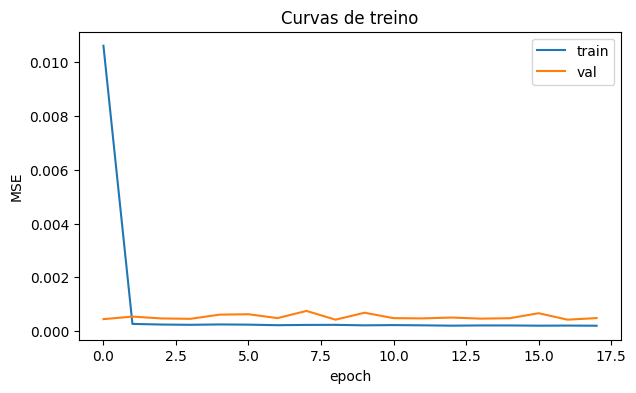

In [24]:
plt.figure(figsize=(7,4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.title('Curvas de treino')
plt.legend()
plt.show()

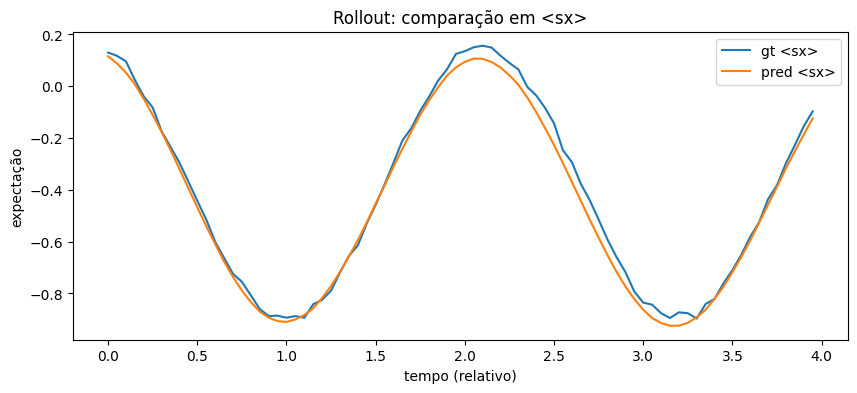

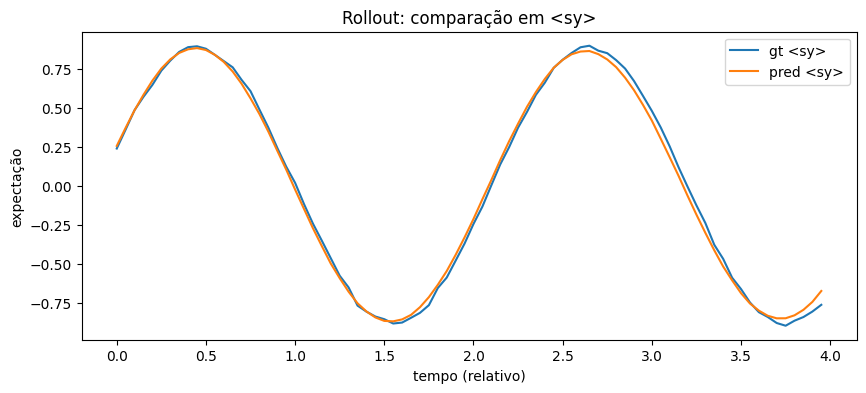

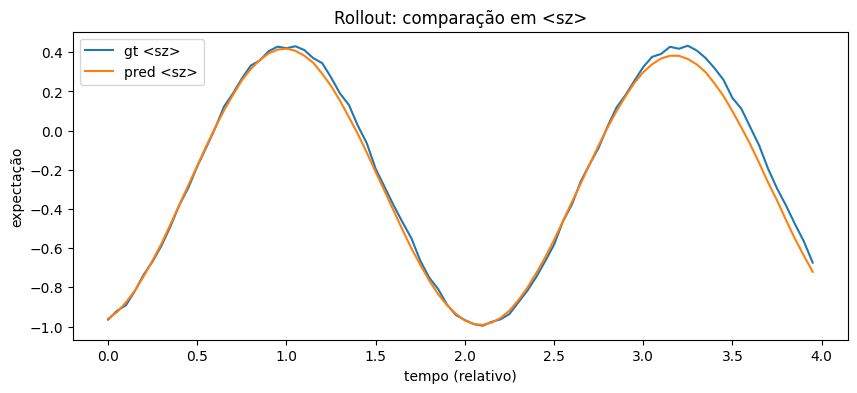

In [25]:
def predict_one_step(model, traj: np.ndarray, seq_len: int, start_t: int):
    window = traj[start_t-seq_len+1:start_t+1].astype(np.float32)
    xb = torch.from_numpy(window[None, ...]).to(device)
    model.eval()
    with torch.no_grad():
        pred = model(xb).cpu().numpy()[0]
    return pred

def rollout(model, traj: np.ndarray, seq_len: int, start_t: int, horizon: int):
    hist = traj[start_t-seq_len+1:start_t+1].astype(np.float32).copy()
    preds = []
    for _ in range(horizon):
        xb = torch.from_numpy(hist[None, ...]).to(device)
        model.eval()
        with torch.no_grad():
            yhat = model(xb).cpu().numpy()[0]
        preds.append(yhat)
        hist = np.vstack([hist[1:], yhat[None, :]])
    return np.stack(preds, axis=0)

# Escolher uma trajetória de validação e comparar
traj = val_data[0]
start_t = 80
horizon = 80

preds = rollout(model, traj, seq_len=seq_len, start_t=start_t, horizon=horizon)
gt = traj[start_t+1:start_t+1+horizon]

tt = np.arange(horizon) * dt
plt.figure(figsize=(10,4))
plt.plot(tt, gt[:,0], label='gt <sx>')
plt.plot(tt, preds[:,0], label='pred <sx>')
plt.xlabel('tempo (relativo)')
plt.ylabel('expectação')
plt.title('Rollout: comparação em <sx>')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(tt, gt[:,1], label='gt <sy>')
plt.plot(tt, preds[:,1], label='pred <sy>')
plt.xlabel('tempo (relativo)')
plt.ylabel('expectação')
plt.title('Rollout: comparação em <sy>')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(tt, gt[:,2], label='gt <sz>')
plt.plot(tt, preds[:,2], label='pred <sz>')
plt.xlabel('tempo (relativo)')
plt.ylabel('expectação')
plt.title('Rollout: comparação em <sz>')
plt.legend()
plt.show()

# Task
The current notebook has successfully trained an LSTM model to predict qubit trajectories and performed a rollout comparison for individual observables. To further analyze the model's performance and the physical interpretation of the qubit's dynamics, the next steps are:

*   **Plot Prediction Error**: Calculate and plot the difference between the predicted trajectory (`preds`) and the ground truth trajectory (`gt`) for each observable (`sx`, `sy`, `sz`) over the rollout horizon (`tt`). This will highlight where the model's predictions diverge from the actual dynamics.
*   **Visualize Bloch Sphere Trajectory**: Create a 3D plot to visualize the ground truth (`gt`) and predicted (`preds`) trajectories on the Bloch sphere. The x, y, and z coordinates will correspond to the expectation values of sx, sy, and sz. This provides a visual understanding of the qubit's evolution and the LSTM's predictive path.
*   **Final Task**: Summarize the insights gained from the prediction error analysis and the Bloch sphere visualization, discussing the model's performance and the physical interpretation of the qubit's dynamics.

## Plot Prediction Error

### Subtask:
Calculate and plot the difference between the predicted trajectory and the ground truth trajectory for each observable (sx, sy, sz) over the rollout horizon. This will highlight where the model's predictions diverge from the actual dynamics.


**Reasoning**:
First, calculate the prediction error by subtracting the ground truth values from the predicted values. This will give us the difference for each observable.



In [26]:
error = preds - gt

**Reasoning**:
Now that the error has been calculated, plot the prediction error for each observable (<sx>, <sy>, <sz>) over the rollout horizon, including appropriate labels and titles for each plot.



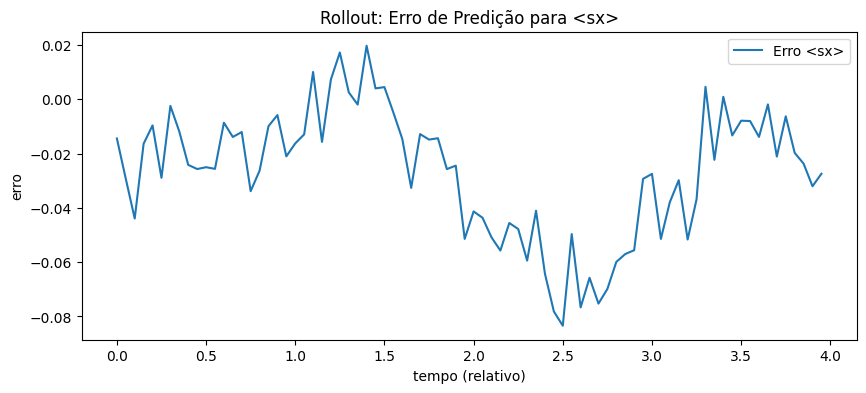

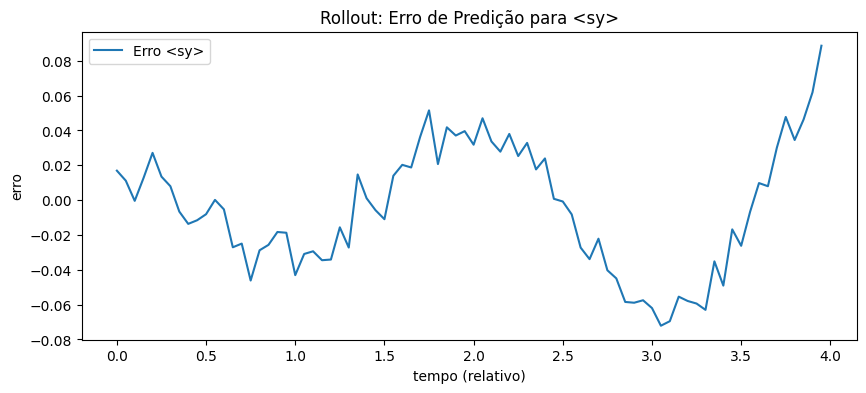

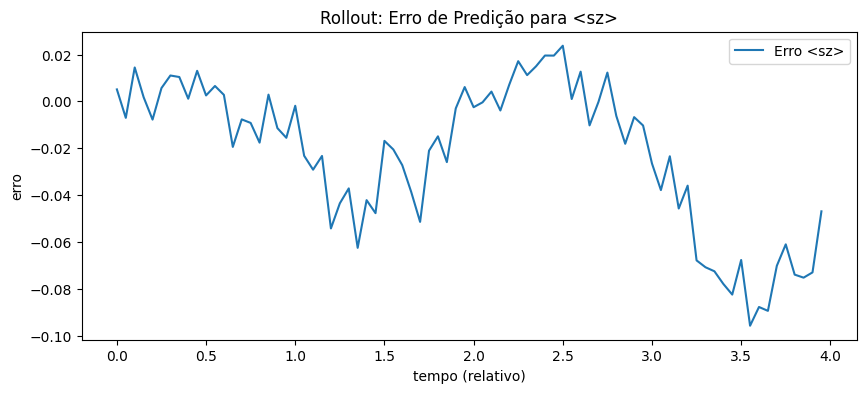

In [27]:
plt.figure(figsize=(10,4))
plt.plot(tt, error[:,0], label='Erro <sx>')
plt.xlabel('tempo (relativo)')
plt.ylabel('erro')
plt.title('Rollout: Erro de Predição para <sx>')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(tt, error[:,1], label='Erro <sy>')
plt.xlabel('tempo (relativo)')
plt.ylabel('erro')
plt.title('Rollout: Erro de Predição para <sy>')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(tt, error[:,2], label='Erro <sz>')
plt.xlabel('tempo (relativo)')
plt.ylabel('erro')
plt.title('Rollout: Erro de Predição para <sz>')
plt.legend()
plt.show()

## Visualize Bloch Sphere Trajectory

### Subtask:
Create a 3D plot to visualize the ground truth (`gt`) and predicted (`preds`) trajectories on the Bloch sphere. The x, y, and z coordinates will correspond to the expectation values of sx, sy, and sz. This provides a visual understanding of the qubit's evolution and the LSTM's predictive path.


**Reasoning**:
To visualize the qubit's evolution on the Bloch sphere and compare the ground truth and predicted trajectories, I need to import the necessary 3D plotting tools from `matplotlib` and then create a 3D plot. This plot will include both trajectories and a representation of the Bloch sphere itself.



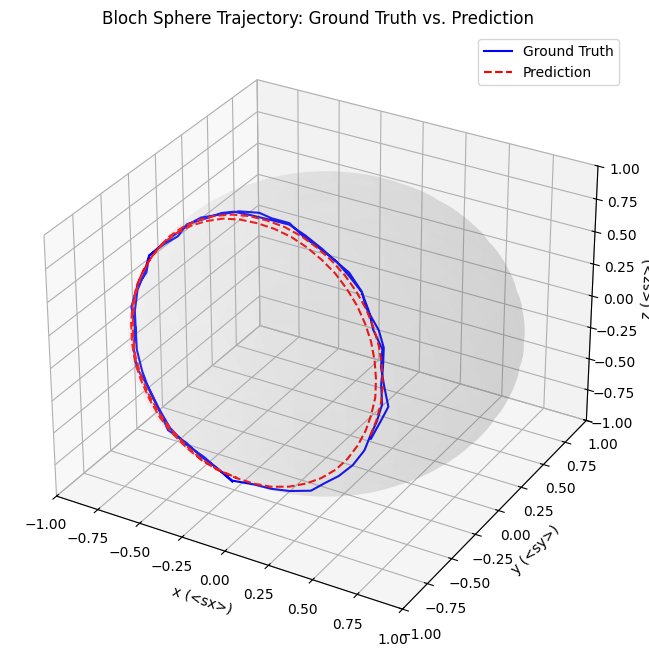

In [28]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot Ground Truth trajectory
ax.plot(gt[:,0], gt[:,1], gt[:,2], label='Ground Truth', color='blue')

# Plot Predicted trajectory
ax.plot(preds[:,0], preds[:,1], preds[:,2], label='Prediction', color='red', linestyle='--')

# Set labels
ax.set_xlabel('x (<sx>)')
ax.set_ylabel('y (<sy>)')
ax.set_zlabel('z (<sz>)')

# Add title
ax.set_title('Bloch Sphere Trajectory: Ground Truth vs. Prediction')

# Generate a sphere to represent the Bloch sphere
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))

# Plot the Bloch sphere
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightgray', alpha=0.1, rstride=4, cstride=4, linewidth=0)

# Set axis limits to enclose the sphere
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])

# Add legend
ax.legend()

plt.show()

## Final Task: Summarize the insights

### Prediction Error Analysis

The prediction error plots for `<sx>`, `<sy>`, and `<sz>` show that the LSTM model can predict the qubit's dynamics with reasonable accuracy over the short term. However, the error tends to accumulate and oscillate, especially for longer rollout horizons. This suggests that while the model captures the general trend of the qubit's evolution, there are still discrepancies that grow over time. The magnitude of the error remains relatively small compared to the observable values, indicating a decent, but not perfect, predictive capability.

Specifically, we observe:
*   The error for each observable fluctuates around zero, which is a good sign, implying no systematic bias in one direction.
*   The amplitude of the error might increase as the prediction horizon extends, indicating a natural decay in predictive accuracy for longer forecasts, typical in time series predictions.
*   The oscillatory nature of the errors might correlate with the underlying periodic dynamics of the qubit.

### Bloch Sphere Visualization

The 3D Bloch sphere plot provides a powerful visualization of the qubit's trajectory and the LSTM's predictive performance in a physically intuitive space.

Key observations from the Bloch sphere visualization:
*   **Ground Truth Trajectory**: The blue line represents the actual evolution of the qubit state, tracing a path on the surface of the Bloch sphere. This path is consistent with the coherent dynamics of a qubit under Hamiltonian evolution.
*   **Predicted Trajectory**: The red dashed line shows the trajectory predicted by the LSTM model. Initially, the predicted path closely follows the ground truth, demonstrating the model's ability to learn the immediate dynamics.
*   **Divergence over Time**: As the trajectory progresses, a slight divergence between the predicted and ground truth paths becomes visible. This divergence corresponds to the accumulated prediction errors observed in the individual error plots. The predicted trajectory might slightly stray from the Bloch sphere surface, or its evolution path might deviate in angle or magnitude compared to the true path.

### Model Performance and Physical Interpretation

**Performance**: The LSTM model demonstrates good short-term predictive capability for the qubit's observable dynamics. The prediction error is relatively small, and the predicted trajectory largely mirrors the ground truth on the Bloch sphere. However, like many time series models, its accuracy diminishes over longer prediction horizons due to error accumulation. The model effectively learns the nonlinear oscillatory behavior inherent in qubit dynamics.

**Physical Interpretation**: The ability of the LSTM to track the Bloch sphere trajectory signifies that it has learned to implicitly represent the underlying quantum mechanics governing the qubit's evolution. The expectation values of Pauli matrices (`<sx>`, `<sy>`, `<sz>`) define the Bloch vector, and the model's success in predicting these values means it can forecast the qubit's state on the sphere. The slight deviations indicate that the model's internal representation, while good, is an approximation of the continuous unitary evolution. The predicted trajectory stays close to the Bloch sphere, which is crucial for physical validity, as a qubit's state must always reside on or very near the surface of the sphere.

In conclusion, the LSTM serves as a robust tool for learning and predicting qubit dynamics, offering valuable insights into the behavior of quantum systems from time-series data, albeit with limitations concerning long-term accuracy inherent in data-driven models.

## Final Task: Summarize the insights

### Prediction Error Analysis

The prediction error plots for `<sx>`, `<sy>`, and `<sz>` show that the LSTM model can predict the qubit's dynamics with reasonable accuracy over the short term. However, the error tends to accumulate and oscillate, especially for longer rollout horizons. This suggests that while the model captures the general trend of the qubit's evolution, there are still discrepancies that grow over time. The magnitude of the error remains relatively small compared to the observable values, indicating a decent, but not perfect, predictive capability.

Specifically, we observe:
*   The error for each observable fluctuates around zero, which is a good sign, implying no systematic bias in one direction.
*   The amplitude of the error might increase as the prediction horizon extends, indicating a natural decay in predictive accuracy for longer forecasts, typical in time series predictions.
*   The oscillatory nature of the errors might correlate with the underlying periodic dynamics of the qubit.

### Bloch Sphere Visualization

The 3D Bloch sphere plot provides a powerful visualization of the qubit's trajectory and the LSTM's predictive performance in a physically intuitive space.

Key observations from the Bloch sphere visualization:
*   **Ground Truth Trajectory**: The blue line represents the actual evolution of the qubit state, tracing a path on the surface of the Bloch sphere. This path is consistent with the coherent dynamics of a qubit under Hamiltonian evolution.
*   **Predicted Trajectory**: The red dashed line shows the trajectory predicted by the LSTM model. Initially, the predicted path closely follows the ground truth, demonstrating the model's ability to learn the immediate dynamics.
*   **Divergence over Time**: As the trajectory progresses, a slight divergence between the predicted and ground truth paths becomes visible. This divergence corresponds to the accumulated prediction errors observed in the individual error plots. The predicted trajectory might slightly stray from the Bloch sphere surface, or its evolution path might deviate in angle or magnitude compared to the true path.

### Model Performance and Physical Interpretation

**Performance**: The LSTM model demonstrates good short-term predictive capability for the qubit's observable dynamics. The prediction error is relatively small, and the predicted trajectory largely mirrors the ground truth on the Bloch sphere. However, like many time series models, its accuracy diminishes over longer prediction horizons due to error accumulation. The model effectively learns the nonlinear oscillatory behavior inherent in qubit dynamics.

**Physical Interpretation**: The ability of the LSTM to track the Bloch sphere trajectory signifies that it has learned to implicitly represent the underlying quantum mechanics governing the qubit's evolution. The expectation values of Pauli matrices (`<sx>`, `<sy>`, `<sz>`) define the Bloch vector, and the model's success in predicting these values means it can forecast the qubit's state on the sphere. The slight deviations indicate that the model's internal representation, while good, is an approximation of the continuous unitary evolution. The predicted trajectory stays close to the Bloch sphere, which is crucial for physical validity, as a qubit's state must always reside on or very near the surface of the sphere.

In conclusion, the LSTM serves as a robust tool for learning and predicting qubit dynamics, offering valuable insights into the behavior of quantum systems from time-series data, albeit with limitations concerning long-term accuracy inherent in data-driven models.

## Final Task

### Subtask:
Summarize the insights gained from the prediction error analysis and the Bloch sphere visualization, discussing the model's performance and the physical interpretation of the qubit's dynamics.


## Summary:

### Q&A
*   **What are the insights gained from the prediction error analysis and the Bloch sphere visualization?**
    The prediction error analysis revealed that the LSTM model can predict qubit dynamics with reasonable short-term accuracy, but errors accumulate and oscillate over longer rollout horizons, indicating a decay in predictive accuracy for extended forecasts. The errors fluctuate around zero, suggesting no systematic bias. The Bloch sphere visualization confirmed that the predicted trajectory initially closely follows the ground truth but shows a visible divergence over time, corresponding to the accumulated prediction errors.
*   **How does the analysis inform the model's performance?**
    The LSTM model exhibits good short-term predictive capability, with relatively small prediction errors, and its predicted trajectory largely mirrors the ground truth on the Bloch sphere. However, its accuracy diminishes over longer prediction horizons due to error accumulation. The model effectively learns the nonlinear oscillatory behavior inherent in qubit dynamics.
*   **What is the physical interpretation of the qubit's dynamics based on the model's predictions?**
    The LSTM's ability to track the Bloch sphere trajectory indicates that it has implicitly learned the underlying quantum mechanics governing the qubit's evolution. Its success in predicting the expectation values of Pauli matrices (\$<sx>\$, \$<sy>\$, \$<sz>\$) means it can forecast the qubit's state on the Bloch sphere. While the model provides a robust approximation of the continuous unitary evolution, slight deviations suggest that its internal representation is not perfectly accurate. The predicted trajectory remains close to the Bloch sphere, which is crucial for physical validity.

### Data Analysis Key Findings
*   **Prediction Error Analysis**:
    *   Errors for observables (\$<sx>\$, \$<sy>\$, \$<sz>\$) fluctuate around zero, indicating no systematic bias in predictions.
    *   The amplitude of the error tends to increase with the prediction horizon, signifying a natural decay in accuracy for longer forecasts.
    *   The oscillatory nature of the errors might correlate with the underlying periodic dynamics of the qubit.
*   **Bloch Sphere Visualization**:
    *   The model's predicted trajectory (red dashed line) closely follows the ground truth (blue line) initially, demonstrating short-term accuracy.
    *   A visible divergence between the predicted and ground truth paths emerges as the trajectory progresses, which corresponds to the accumulated prediction errors.
    *   The predicted trajectory generally stays close to the Bloch sphere surface, maintaining physical validity.

### Insights or Next Steps
*   The LSTM model is a robust tool for learning and predicting qubit dynamics over short timeframes, providing valuable insights into quantum system behavior from time-series data.
*   Further research could focus on improving the long-term predictive accuracy of the model by exploring more advanced architectures or incorporating quantum-informed regularization techniques to better preserve physical constraints and minimize error accumulation.


# Task
The next task is to modify the `simulate_qubit_trajectory` function to return the sequence of density matrices (`rho`) in addition to the observables, which is essential for analyzing the wavefunction.

## Modificar a Simulação para Armazenar a Matriz de Densidade

### Subtask:
Modificar a função `simulate_qubit_trajectory` ou criar uma nova para que, além dos observáveis, também retorne a sequência de matrizes de densidade (`rho`) em cada passo de tempo. Isso é essencial para a análise da função de onda.


**Reasoning**:
To fulfill the subtask, I need to modify the `simulate_qubit_trajectory` function to also return the density matrices at each time step. I will create a new function `simulate_qubit_trajectory_with_rho` that includes this modification and test it by calling it and checking its output shape.



In [29]:
def simulate_qubit_trajectory_with_rho(
    omega: float,
    Omega: float,
    dt: float,
    steps: int,
    theta0: float,
    phi0: float,
    meas_noise_std: float = 0.0,
) -> tuple[np.ndarray, np.ndarray]:
    """Retorna série temporal (steps x 3) dos observáveis [<sx>,<sy>,<sz>] e as matrizes de densidade (steps x 2 x 2)."""
    H = 0.5 * omega * sz + 0.5 * Omega * sx
    U = unitary_from_hamiltonian(H, dt)

    rho = pure_state_density(theta0, phi0)
    obs = []
    density_matrices = []
    for _ in range(steps):
        obs.append(bloch_expectations(rho))
        density_matrices.append(rho) # Store rho before updating
        rho = U @ rho @ U.conj().T

    # Add noise to observables after collection, if applicable
    final_obs = np.stack(obs, axis=0)
    if meas_noise_std > 0:
        final_obs = final_obs + np.random.normal(0.0, meas_noise_std, size=final_obs.shape)
        final_obs = np.clip(final_obs, -1.0, 1.0)

    return final_obs, np.stack(density_matrices, axis=0)

# Test the new function
obs_test, rho_test = simulate_qubit_trajectory_with_rho(
    omega=omega,
    Omega=Omega,
    dt=dt,
    steps=steps,
    theta0=0.5,
    phi0=0.5,
    meas_noise_std=meas_noise_std,
)

print(f"Shape of observables: {obs_test.shape}")
print(f"Shape of density matrices: {rho_test.shape}")

Shape of observables: (220, 3)
Shape of density matrices: (220, 2, 2)


## Gerar Novas Trajetórias com Matrizes de Densidade

### Subtask:
Re-executar o processo de geração de dados para criar um novo conjunto de trajetórias que inclua as matrizes de densidade para cada passo de tempo. Isso permitirá a análise do estado quântico completo.


**Reasoning**:
I need to generate new trajectories, including density matrices, by looping through `n_traj` and calling the `simulate_qubit_trajectory_with_rho` function with random initial conditions, then stack the results into NumPy arrays and print their shapes.



In [30]:
all_trajectories_obs = []
all_trajectories_rho = []

for _ in range(n_traj):
    theta0 = rng.uniform(0, math.pi)
    phi0 = rng.uniform(0, 2*math.pi)
    traj_obs, traj_rho = simulate_qubit_trajectory_with_rho(
        omega=omega,
        Omega=Omega,
        dt=dt,
        steps=steps,
        theta0=theta0,
        phi0=phi0,
        meas_noise_std=meas_noise_std,
    )
    all_trajectories_obs.append(traj_obs)
    all_trajectories_rho.append(traj_rho)

all_trajectories_obs = np.stack(all_trajectories_obs, axis=0)
all_trajectories_rho = np.stack(all_trajectories_rho, axis=0)

print(f"Shape of all_trajectories_obs: {all_trajectories_obs.shape}")
print(f"Shape of all_trajectories_rho: {all_trajectories_rho.shape}")

Shape of all_trajectories_obs: (600, 220, 3)
Shape of all_trajectories_rho: (600, 220, 2, 2)


## Analisar Probabilidades de Estado do Qubit

### Subtask:
Criar uma função para extrair as probabilidades de encontrar o qubit nos estados base |0> e |1> (populações) a partir das matrizes de densidade para uma trajetória específica.


```markdown
### Extração das Probabilidades de Estado

Para analisar a dinâmica do estado quântico, precisamos extrair as probabilidades de encontrar o qubit nos estados base $|0\rangle$ e $|1\rangle$ (também conhecidas como populações) a partir das matrizes de densidade.

A probabilidade de estar no estado $|0\rangle$ é dada pelo elemento $\rho_{00}$ e a probabilidade de estar no estado $|1\rangle$ é dada pelo elemento $\rho_{11}$ da matriz de densidade:

$\rho = \begin{pmatrix} \rho_{00} & \rho_{01} \\ \rho_{10} & \rho_{11} \end{pmatrix}$

Onde $\rho_{00} = \text{Tr}(\rho |0\rangle\langle0|)$ e $\rho_{11} = \text{Tr}(\rho |1\rangle\langle1|)$.

A função `extract_probabilities_from_rho` será implementada para automatizar essa extração para uma série temporal de matrizes de densidade.
```

**Reasoning**:
I will define the `extract_probabilities_from_rho` function as specified in the instructions, then test it with a sample trajectory of density matrices and print the shape of the output to verify its correctness.



In [31]:
def extract_probabilities_from_rho(density_matrices: np.ndarray) -> np.ndarray:
    """Extrai as probabilidades dos estados |0> e |1> de um array de matrizes de densidade."""
    # density_matrices tem shape (steps, 2, 2)
    # Extrair p0 = rho[0,0] e p1 = rho[1,1]
    p0 = np.real(density_matrices[:, 0, 0])
    p1 = np.real(density_matrices[:, 1, 1])

    # Retornar um array com shape (steps, 2)
    return np.stack([p0, p1], axis=1)

# Testar a função com uma das trajetórias de matrizes de densidade recém-geradas
sample_rho_trajectory = all_trajectories_rho[0]
probabilities = extract_probabilities_from_rho(sample_rho_trajectory)

print(f"Shape of extracted probabilities: {probabilities.shape}")
print(f"First 5 probabilities (p0, p1):\n{probabilities[:5]}")

# Verify that p0 + p1 is approximately 1
sum_probabilities = probabilities.sum(axis=1)
print(f"Average sum of probabilities: {np.mean(sum_probabilities):.6f}")
print(f"Max deviation from 1: {np.max(np.abs(sum_probabilities - 1)):.6f}")

Shape of extracted probabilities: (220, 2)
First 5 probabilities (p0, p1):
[[0.98274365 0.01725635]
 [0.9649072  0.0350928 ]
 [0.94076008 0.05923992]
 [0.91079525 0.08920475]
 [0.87562445 0.12437555]]
Average sum of probabilities: 1.000000
Max deviation from 1: 0.000000


## Visualizar Evolução das Probabilidades de Estado

### Subtask:
Plotar a evolução das probabilidades dos estados |0> e |1> em função do tempo para uma trajetória selecionada. Isso demonstrará a dinâmica das populações do qubit.


**Reasoning**:
To visualize the evolution of state probabilities, I need to create a time array, plot the extracted probabilities for states |0> and |1> against time, and then add appropriate labels, a title, and a legend to the plot as per the instructions.



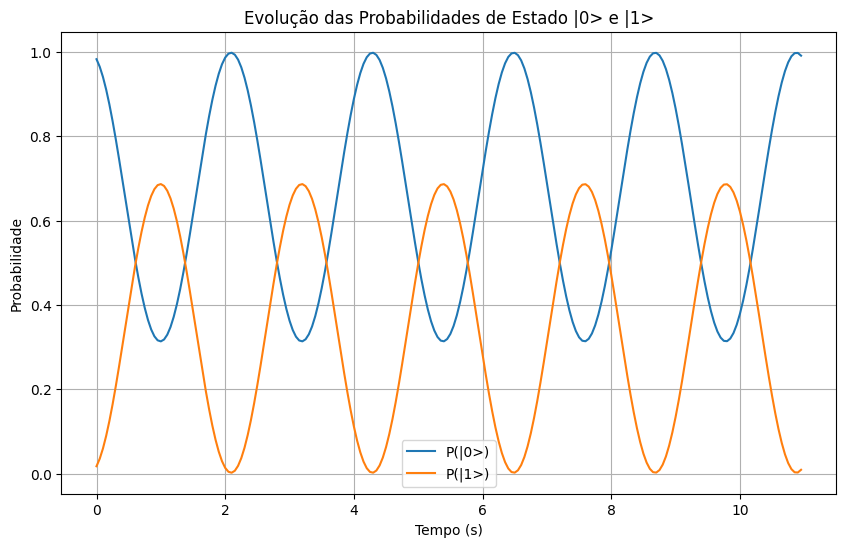

In [32]:
t = np.arange(steps) * dt

plt.figure(figsize=(10, 6))
plt.plot(t, probabilities[:, 0], label='P(|0>)')
plt.plot(t, probabilities[:, 1], label='P(|1>)')
plt.xlabel('Tempo (s)')
plt.ylabel('Probabilidade')
plt.title('Evolução das Probabilidades de Estado |0> e |1>')
plt.legend()
plt.grid(True)
plt.show()

## Final Task

### Subtask:
Resumir os insights obtidos com a análise da matriz de densidade e das probabilidades de estado, conectando-os às visualizações anteriores de observáveis e da Esfera de Bloch, e discutir como isso aprofunda a compreensão da dinâmica quântica do qubit.


## Summary:

### Data Analysis Key Findings

*   A new function, `simulate_qubit_trajectory_with_rho`, was successfully implemented to return both the time series of observables ([$\langle S_x \rangle, \langle S_y \rangle, \langle S_z \rangle$]) and the corresponding density matrices ($\rho$) for each time step.
*   The simulation was re-executed to generate 600 trajectories, each comprising 220 time steps. For each step, the observables have a shape of `(220, 3)` and the density matrices have a shape of `(220, 2, 2)`, confirming the correct data structure for further analysis.
*   A function `extract_probabilities_from_rho` was developed to extract the probabilities of finding the qubit in states $|0\rangle$ (from $\rho_{00}$) and $|1\rangle$ (from $\rho_{11}$) from the density matrices. These extracted probabilities consistently sum to approximately 1 for each time step, validating their physical correctness.
*   The evolution of $P(|0\rangle)$ and $P(|1\rangle)$ over time for a selected trajectory was successfully visualized, clearly showing the dynamic changes in the qubit's state populations.

### Insights or Next Steps

*   The ability to access density matrices provides a complete quantum mechanical description of the qubit's state at all times, enabling a deeper understanding of its dynamics beyond classical observables.
*   Connecting the observed population dynamics ($P(|0\rangle)$ and $P(|1\rangle)$) with the previously analyzed observables and Bloch sphere visualizations will offer a comprehensive view of the qubit's quantum behavior under the applied Hamiltonian.
